In [ ]:
# 실습 환경 준비 — 신호 분석 함수 모음(utils.py) 다운로드
import os

if not os.path.exists('utils.py'):
    import gdown
    gdown.download(id='1xUhiEs74qyyno0ZrZNHmF7KXPe_QZwsD', output='utils.py', quiet=True)

print('실습 환경 준비 완료 — Working directory:', os.getcwd())


# 리샘플링과 Order Analysis — 비정상 회전 신호 분석 + TSA

## 학습 목표
- 회전 속도가 변하는 신호에서 시간 영역 FFT 가 퍼지는 현상과 각도 기반 리샘플링 (order tracking) 을 다룬다
- 정수 회전수를 맞춰 Order 스펙트럼의 leakage 를 방지한다
- TSA (Time Synchronous Averaging) 로 주기적 이상치를 드러낸다
- GMF·사이드밴드 성분을 제거한 잔차(residual)·차이(difference) 신호와 포락선 스펙트럼을 분석한다
- 기어 상태 피처와 cepstrum·EEMD·웨이블릿 분석으로 정상/고장을 정량 비교한다

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from utils import fft, resampling, hilbert_envelope

---

## 실습 준비 1. 신호 생성 — 회전속도가 변하는 기어 신호

- 회전 속도 $f_{rot}(t) = 1 + t$ [Hz], 누적 위상 $\phi(t) = \int_0^t f_{rot}\,d\tau$
- 기어 이빨 `n_gear = 15`개 + 축 1x 진폭 변조 → GMF(Order 15)와 사이드밴드(Order 14, 16)

$$v(t) = \left(1 + m_{AM}\sin(2\pi\phi)\right)\,\sin(n_{gear}\cdot 2\pi\phi)$$

In [ ]:
fs = 1000
T = 20
t = np.arange(1/fs, T + 1/fs, 1/fs)
n_gear = 15

f_rotation = 1 + t                       # 순시 회전 주파수 (Hz)
phase_deg = np.cumsum(f_rotation) * 360 / fs
phase_rad = 2 * np.pi * phase_deg / 360

# 축 1x 진폭 변조 → 사이드밴드 (Order 14, 16)
m_AM = 0.2
v = (1 + m_AM * np.sin(phase_rad)) * np.sin(n_gear * phase_rad)

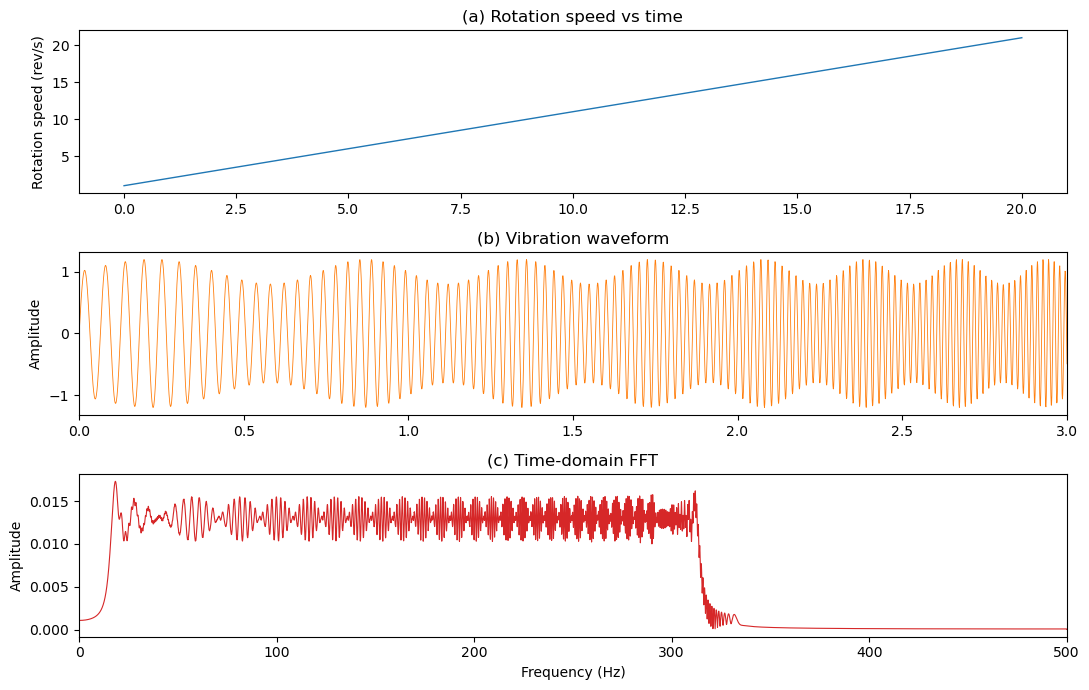

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7))

axes[0].plot(t, f_rotation, color='C0', lw=1.0)
axes[0].set_ylabel('Rotation speed (rev/s)')
axes[0].set_title('(a) Rotation speed vs time')

axes[1].plot(t, v, color='C1', lw=0.6)
axes[1].set_ylabel('Amplitude')
axes[1].set_title('(b) Vibration waveform')
axes[1].set_xlim(0, min(t[-1], 3))

f_time, A_time = fft(v, fs)
axes[2].plot(f_time, A_time, color='C3', lw=0.8)
axes[2].set_xlim(0, 500); axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_title('(c) Time-domain FFT')

plt.tight_layout(); plt.show()

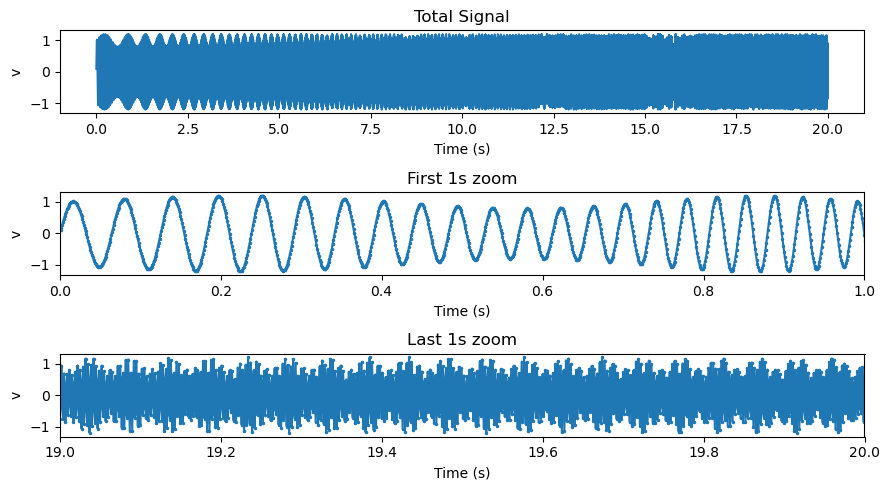

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(9, 5))
axes[0].plot(t, v, color='C0')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('v')
axes[0].set_title('Total Signal')
axes[1].plot(t, v, '.-', color='C0', markersize=3)
axes[1].set_xlim([0, 1])
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('v')
axes[1].set_title('First 1s zoom')
axes[2].plot(t, v, '.-', color='C0', markersize=3)
axes[2].set_xlim([19, 20])
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('v')
axes[2].set_title('Last 1s zoom')
fig.tight_layout(); plt.show()

---

## 실습 1. 리샘플링 실습

### 시간 영역 FFT — 스펙트럼이 퍼지는 현상

회전 속도가 시간에 따라 변하면, 같은 기어 주파수 성분이 여러 주파수에 걸쳐 퍼져 나타난다.

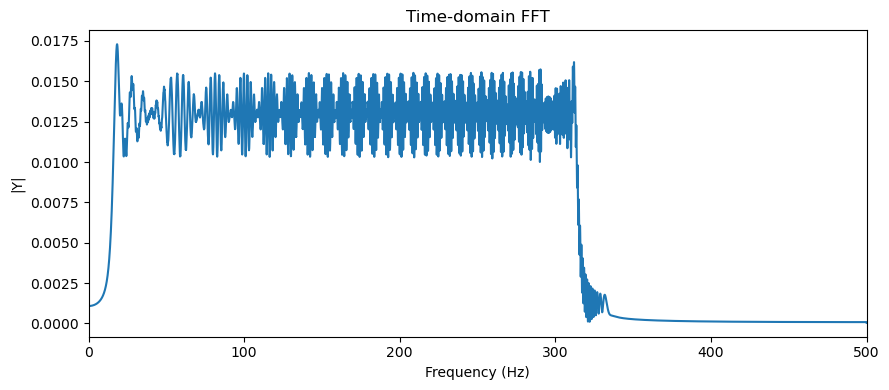

In [ ]:
f, A = fft(v, fs)

plt.figure(figsize=(9, 4))
plt.plot(f, A, color='C0')
plt.xlim([0, 500])
plt.xlabel('Frequency (Hz)'); plt.ylabel('|Y|')
plt.title('Time-domain FFT')
plt.tight_layout(); plt.show()

---

### 각도 기반 리샘플링 — Resampling Frequency 결정

- 전체 회전수 $N_{rot} = \phi_{\text{end}} / 360$
- 회전 1바퀴당 샘플 수 `fs_re` 를 결정 (데이터 기반 추정치를 참고, 여기서는 100으로 지정)

In [ ]:
N_rot = phase_deg[-1] / 360
N_samples = len(v)
fs_re_est = np.floor(N_samples / N_rot)

print(f'Total rotations              : {N_rot:.2f}')
print(f'Total samples                 : {N_samples}')
print(f'Samples per rotation (est.)   : {fs_re_est:.0f}')

fs_re = 100  # 회전 1바퀴당 100 샘플로 리샘플링

Total rotations              : 220.01
Total samples                 : 20000
Samples per rotation (est.)   : 90


---

### 리샘플링 직접 구현 — 원리 이해

1. 각도 축에 등간격 격자 생성 (`degree_re_delta = 360 / fs_re`)
2. 각도-시간 보간: 등간격 각도에 해당하는 시간 `t_re`
3. 시간-신호 보간: `t_re` 시점의 신호 값 `v_re`
4. 정수 회전수 맞추기: 길이가 `fs_re` 의 배수가 되도록 뒤쪽을 잘라낸다 — 성분이 Order bin 중심에 정확히 놓여 leakage 가 생기지 않는다

In [ ]:
starting = phase_deg[0]
ending = phase_deg[-1]
degree_re_delta = 360 / fs_re
degree_re = np.arange(starting + degree_re_delta, ending - degree_re_delta, degree_re_delta)

fx_t_re = interp1d(phase_deg, t)
t_re = fx_t_re(degree_re)

fx_v_re = interp1d(t, v)
v_re = fx_v_re(t_re)

# 정수 회전수 맞추기 — 마지막 불완전한 회전 구간은 잘라낸다
rem = len(v_re) % fs_re
if rem > 0:
    t_re = t_re[:-rem]
    degree_re = degree_re[:-rem]
    v_re = v_re[:-rem]

print(f'Number of resampling points: {len(v_re)} (= {len(v_re) // fs_re} rotations x {fs_re} samples)')
print(f'First 4 angles    : {degree_re[:4]}')
print(f'Last 4 angles    : {degree_re[-4:]}')


---

### Order Analysis — 각도 축 FFT

리샘플링된 신호를 FFT 하면 주파수 축이 **Order** (회전당 주기 수) 축으로 바뀐다. 기어 이빨 수 `n_gear = 15` 이므로 **Order = 15** 에 첨예한 피크가, 좌우 **Order = 14, 16** 에 사이드밴드가 나타나야 한다.

In [ ]:
order, order_A = fft(v_re, fs_re)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(order, order_A, color='C0')
axes[0].set_xlabel('Order'); axes[0].set_ylabel('|Y|')
axes[0].set_title('Total Order Spectrum')
axes[1].plot(order, order_A, '-o', color='C0', markersize=4)
axes[1].set_xlim([13.8, 16.2])
axes[1].set_xlabel('Order'); axes[1].set_ylabel('|Y|')
axes[1].set_title('Zoom (GMF & sidebands)')
fig.tight_layout(); plt.show()

---

### utils.resampling 함수 활용

위 과정 전체가 `utils.resampling` 함수 하나에 들어 있다. 기본값 `trig_rot=1` 이 정수 회전수 절단까지 수행하므로, 직접 구현과 같은 결과를 얻는다.


In [ ]:
t_re2, v_re2, degree_re2, fs_re = resampling(t, v, phase_deg, fs_re)

print(f'직접 구현 : {len(v_re)} samples')
print(f'함수 사용 : {len(v_re2)} samples')
print(f'두 결과가 일치하는가? {np.allclose(v_re, v_re2)}')

order, order_A = fft(v_re2, fs_re)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(order, order_A, color='C0')
axes[0].set_xlabel('Order'); axes[0].set_ylabel('|Y|')
axes[0].set_title('utils.resampling: Total Order Spectrum')
axes[1].plot(order, order_A, '-o', color='C0', markersize=4)
axes[1].set_xlim([13.8, 16.2])
axes[1].set_xlabel('Order'); axes[1].set_ylabel('|Y|')
axes[1].set_title('utils.resampling: Zoom (GMF & sidebands)')
fig.tight_layout(); plt.show()


---

## 실습 준비 2. 고장 신호 생성 — 이상치와 노이즈

### 주기적 이상치 추가 (정상 vs 고장)

각 회전마다 동일한 위치(40번째 샘플)에 진폭 0.8 펄스를 더해 기어 1바퀴당 1회 이상치가 나타나는 고장 신호를 만든다.

In [ ]:
v_re_f = np.copy(v_re)                # fault
v_re_n = np.copy(v_re)                # normal
idx_fault = np.arange(40, len(v_re_f), fs_re)
v_re_f[idx_fault] = v_re_f[idx_fault] + 0.8

fig, axes = plt.subplots(2, 1, figsize=(9, 5))
axes[0].plot(v_re_f, color='C3', label='Fault')
axes[0].plot(v_re_n, color='C0', alpha=0.5, label='Normal')
axes[0].legend(); axes[0].set_title('Impact added')
axes[1].plot(v_re_f, color='C3', label='Fault')
axes[1].plot(v_re_n, color='C0', alpha=0.5, label='Normal')
axes[1].set_xlim([0, 300]); axes[1].legend()
axes[1].set_title('Zoom')
axes[1].set_xlabel('Samples'); axes[1].set_ylabel('v')
fig.tight_layout(); plt.show()

---

### 노이즈 추가 — 이상치가 가려짐

In [ ]:
np.random.seed(1000)
v_re_f = v_re_f + np.random.randn(len(v_re_f)) / 2
v_re_n = v_re_n + np.random.randn(len(v_re_n)) / 2

plt.figure(figsize=(9, 4))
plt.plot(v_re_f, color='C3', label='Fault')
plt.plot(v_re_n, color='C0', alpha=0.5, label='Normal')
plt.xlim([0, 1000])
plt.xlabel('Samples'); plt.ylabel('v'); plt.legend()
plt.title('Noise added')
plt.tight_layout(); plt.show()

---

## 실습 2. 시간동기평균화 (TSA)

### 신호를 회전주기로 잘라서 평균

- 5 회전(`5 * fs_re` 샘플)씩 reshape 후 평균 (길이를 `seg_len` 배수로 절단하는 안전장치 포함)
- 회전 동기 성분은 남고 비동기 노이즈는 $1/\sqrt{N}$ 로 억제

In [ ]:
n_rot_TSA = 5
seg_len = n_rot_TSA * fs_re

# 안전장치: v_re 길이를 seg_len 배수로 맞춤
n_full = (len(v_re_f) // seg_len) * seg_len
v_re_f = v_re_f[:n_full]
v_re_n = v_re_n[:n_full]

v_reshape_f = v_re_f.reshape(seg_len, -1, order='F')
v_TSA_f = np.mean(v_reshape_f, axis=1)

v_reshape_n = v_re_n.reshape(seg_len, -1, order='F')
v_TSA_n = np.mean(v_reshape_n, axis=1)

print(f'segment shape: {v_reshape_f.shape} (seg_len={seg_len}, n_segments={v_reshape_f.shape[1]})')

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
axes[0].plot(v_reshape_f, color='C0', alpha=0.15)
axes[0].plot(v_TSA_f, '--', color='C3', linewidth=2.5, label='TSA Mean')
axes[0].legend(); axes[0].set_title('Segments + TSA mean (Fault)')
axes[1].plot(v_TSA_f, color='C3', label='Fault TSA')
axes[1].plot(v_TSA_n, color='C0', label='Normal TSA')
axes[1].set_xlabel('Samples (5 rotations)'); axes[1].legend()
axes[1].set_title('Fault vs Normal TSA')
fig.tight_layout(); plt.show()

---

### TSA 신호의 주파수 분석

기어 정규 성분은 GMF(Order 15)·고조파(30, 45)와 사이드밴드(14, 16)로, 회전당 1회 반복되는 이상치는 shaft order 1 의 배수(정수 order) 성분으로 나타난다.

In [ ]:
f_raw_n, A_raw_n = fft(v_re_n, fs_re)
f_raw_f, A_raw_f = fft(v_re_f, fs_re)
f_n, A_n = fft(v_TSA_n, fs_re)
f_f, A_f = fft(v_TSA_f, fs_re)

specs = [
    ('Raw', f_raw_n, A_raw_n, f_raw_f, A_raw_f),
    ('TSA', f_n, A_n, f_f, A_f),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for i, (name, fo_n, Ao_n, fo_f, Ao_f) in enumerate(specs):
    for j in range(2):
        axes[i, j].plot(fo_f, Ao_f, color='C3', label='Fault')
        axes[i, j].plot(fo_n, Ao_n, color='C0', alpha=0.7, label='Normal')
        axes[i, j].set_ylabel('|Y|'); axes[i, j].legend()
    axes[i, 0].set_title(f'{name} Spectrum')
    axes[i, 1].set_title(f'{name} Spectrum (Zoom)')
    axes[i, 1].set_ylim([0, 0.05])
axes[1, 0].set_xlabel('Order'); axes[1, 1].set_xlabel('Order')
fig.tight_layout(); plt.show()

---

## 실습 3. 잔차/차이 신호 분석

### Order 성분 제거와 포락선 스펙트럼

TSA 신호에서 정규(regular) 성분 — GMF 고조파(15·30·45)와 사이드밴드(±1) — 을 제거한 신호를 본다. TSA 는 성분이 정확히 bin 중심에 있으므로 해당 bin 을 0 으로 만드는 방식(`remove_orders`)으로 제거한다.

| 파생 신호 | 구성 | 남는 것 |
|---|---|---|
| 잔차 $v_{RES}$ (residual) | TSA − GMF 고조파 | 사이드밴드 + 임펄스 + 노이즈 |
| 차이 $v_{DIF}$ (difference) | TSA − (GMF 고조파 + 사이드밴드) | 임펄스 + 노이즈 |

In [ ]:
# GMF 고조파와 1차 사이드밴드 정의 (n_gear=15, Nyquist = fs_re/2 = 50)
gmf_harmonics = [15, 30, 45]
sidebands = [14, 16, 29, 31, 44, 46]      # 각 GMF 고조파 ± 1 (shaft order = 1)

def remove_orders(v, fs_re, orders, half_width=0.3):
    """FFT 에서 지정 order 근방 bin 을 0으로 만들고 역변환 (order-domain notch)."""
    V = np.fft.rfft(v)
    order_axis = np.fft.rfftfreq(len(v), d=1/fs_re)
    for o in orders:
        V[np.abs(order_axis - o) <= half_width] = 0
    return np.fft.irfft(V, n=len(v))

# residual: GMF 고조파만 제거
v_res_n = remove_orders(v_TSA_n, fs_re, gmf_harmonics)
v_res_f = remove_orders(v_TSA_f, fs_re, gmf_harmonics)

# difference: 사이드밴드까지 제거
v_dif_n = remove_orders(v_TSA_n, fs_re, gmf_harmonics + sidebands)
v_dif_f = remove_orders(v_TSA_f, fs_re, gmf_harmonics + sidebands)

# regular: 제거된 정규 성분
v_reg_n = v_TSA_n - v_dif_n
v_reg_f = v_TSA_f - v_dif_f

signals = [
    ('TSA', v_TSA_n, v_TSA_f),
    ('Residual', v_res_n, v_res_f),
    ('Difference', v_dif_n, v_dif_f),
]
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for i, (name, sn, sf) in enumerate(signals):
    axes[i, 0].plot(sf, color='C3', label='Fault')
    axes[i, 0].plot(sn, color='C0', alpha=0.7, label='Normal')
    axes[i, 0].set_ylabel('Amplitude'); axes[i, 0].legend()
    axes[i, 0].set_title(f'{name} — time')

    fo_n, Ao_n = fft(sn, fs_re)
    fo_f, Ao_f = fft(sf, fs_re)
    axes[i, 1].plot(fo_f, Ao_f, color='C3', label='Fault')
    axes[i, 1].plot(fo_n, Ao_n, color='C0', alpha=0.7, label='Normal')
    axes[i, 1].set_ylim([0, 0.05])
    axes[i, 1].set_ylabel('|Y|'); axes[i, 1].legend()
    axes[i, 1].set_title(f'{name} — order spectrum')
axes[2, 0].set_xlabel('Samples (5 rotations)')
axes[2, 1].set_xlabel('Order')
fig.tight_layout(); plt.show()

In [ ]:
# 포락선 스펙트럼: 힐베르트 포락선 → DC 제거 → FFT
env_signals = [('Raw', v_re_n, v_re_f)] + signals

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
for ax, (name, sn, sf) in zip(axes, env_signals):
    en = hilbert_envelope(sn)
    ef = hilbert_envelope(sf)
    fe_n, Ae_n = fft(en - np.mean(en), fs_re)
    fe_f, Ae_f = fft(ef - np.mean(ef), fs_re)

    for o in range(1, 21):
        ax.axvline(o, color='gray', ls='--', lw=0.6, alpha=0.5)
    ax.plot(fe_f, Ae_f, color='C3', label='Fault')
    ax.plot(fe_n, Ae_n, color='C0', alpha=0.7, label='Normal')
    ax.set_xlim([0, 20])
    ax.set_ylabel('|Y|'); ax.legend()
    ax.set_title(f'{name} — envelope spectrum')
axes[-1].set_xlabel('Order (dashed: 1x harmonics)')
fig.tight_layout(); plt.show()

---

## 실습 4. 기어 피쳐 정의

TSA·잔차·차이 신호에서 스칼라 피처(Condition Indicator)를 계산해 정상/고장을 수치로 비교한다.

| 기반 신호 | 피처 |
|---|---|
| $v_{TSA}$ | FM0, SER |
| $v_{RES}$ | NA4, NA4* |
| $v_{DIF}$ | FM4, M6A, M8A, ER |

- FM0 = peak-to-peak($v_{TSA}$) $/\ \sum_k A_{GMF_k}$
- SER = $\sum A_{sideband} \,/\, A_{GMF_1}$
- NA4 = $N \sum (v_{RES}-\bar{v}_{RES})^4 \,/\, \left(\overline{\sigma^2_{run}}\right)^2$ (분산은 기록 누적 평균), NA4* 는 분모를 정상 상태 분산으로 고정
- FM4 / M6A / M8A = $v_{DIF}$ 의 정규화 4/6/8차 중심 모멘트 (가우시안 기준 3, 15, 105)
- ER = RMS($v_{DIF}$) / RMS(정규 성분)

`gear_features` 함수 하나로 정상·고장에 동일 적용한다 (`var_ref` = 정상 잔차 분산, NA4 reset 은 부하 정보가 필요해 제외).

In [ ]:
def moment_ratio(x, k):
    """정규화 k차 중심 모멘트 = N^(k/2-1) * sum(x0^k) / sum(x0^2)^(k/2)  (k=4 → 첨도)"""
    x0 = x - np.mean(x)
    N = len(x0)
    return N ** (k // 2 - 1) * np.sum(x0 ** k) / np.sum(x0 ** 2) ** (k // 2)

def gear_features(v_TSA, v_res, v_dif, v_reg, fs_re, var_ref=None):
    """한 상태(정상 또는 고장)의 기어 상태 피처 8종 계산.

    var_ref : NA4/NA4* 분산 정규화 기준 (정상 상태 잔차 분산).
              None 이면 자기 자신의 분산 사용 (= 첫 번째 기록인 정상 상태).
    """
    # TSA 기반: FM0, SER
    f_ord, A_ord = fft(v_TSA, fs_re)
    def amp(o):
        return A_ord[np.argmin(np.abs(f_ord - o))]
    FM0 = np.ptp(v_TSA) / sum(amp(o) for o in gmf_harmonics)
    SER = (amp(14) + amp(16)) / amp(15)     # 기본 GMF(15) 의 1차 사이드밴드

    # 잔차 기반: NA4, NA4*
    var_res = np.var(v_res)
    m4 = np.mean((v_res - np.mean(v_res)) ** 4)
    if var_ref is None:
        var_ref = var_res
    NA4 = m4 / np.mean([var_ref, var_res]) ** 2   # 기록들의 평균 분산으로 정규화
    NA4s = m4 / var_ref ** 2                      # 정상 상태 분산으로 고정 정규화

    # 차이 신호 기반: FM4, M6A, M8A, ER
    FM4 = moment_ratio(v_dif, 4)
    M6A = moment_ratio(v_dif, 6)
    M8A = moment_ratio(v_dif, 8)
    ER = np.sqrt(np.mean(v_dif ** 2)) / np.sqrt(np.mean(v_reg ** 2))

    names = ['FM0', 'SER', 'NA4', 'NA4*', 'FM4', 'M6A', 'M8A', 'ER']
    return np.array([FM0, SER, NA4, NA4s, FM4, M6A, M8A, ER]), names

vals_n, names = gear_features(v_TSA_n, v_res_n, v_dif_n, v_reg_n, fs_re)
vals_f, _ = gear_features(v_TSA_f, v_res_f, v_dif_f, v_reg_f, fs_re, var_ref=np.var(v_res_n))

print(f'{"Feature":10s}{"Normal":>12s}{"Fault":>12s}{"Fault/Normal":>14s}')
for name, vn, vf in zip(names, vals_n, vals_f):
    print(f'{name:10s}{vn:12.3f}{vf:12.3f}{vf/vn:14.2f}')

x = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x - 0.2, vals_n, width=0.4, color='C0', label='Normal')
axes[0].bar(x + 0.2, vals_f, width=0.4, color='C3', label='Fault')
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel('Feature value'); axes[0].legend()
axes[0].set_title('Condition Indicators')
axes[1].bar(x, vals_f / vals_n, color='C2')
axes[1].axhline(1, color='gray', ls=':')
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel('Fault / Normal ratio')
axes[1].set_title('Relative Change')
fig.tight_layout(); plt.show()

---

## 실습 5. (심화) Cepstrum

Cepstrum 은 log 스펙트럼의 역 FFT: $c(q) = \mathcal{F}^{-1}\{\log|X|\}$. 스펙트럼의 등간격 구조(고조파·사이드밴드 family)가 quefrency 피크(rahmonic)로 모인다 — 회전당 1회 임펄스는 1 rev 배수 rahmonic. Spectrum → Envelope Spectrum → Cepstrum 을 3×3 으로 비교한다.

In [ ]:
from scipy import stats

def real_cepstrum(x, fs):
    """Real cepstrum: IFFT(log|FFT|). quefrency 단위 = 회전수(rev)."""
    X = np.abs(np.fft.rfft(x))
    X = np.maximum(X, 0.1 * np.median(X))   # 제거된 bin 보호
    c = np.fft.irfft(np.log(X))
    q = np.arange(len(c)) / fs
    return q, c

cep_signals = [
    ('Raw', v_re_n, v_re_f),
    ('TSA', v_TSA_n, v_TSA_f),
    ('DIFF', v_dif_n, v_dif_f),
]
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for j, (name, sn, sf) in enumerate(cep_signals):
    # 1행: Spectrum
    ax = axes[0, j]
    fo_n, Ao_n = fft(sn, fs_re)
    fo_f, Ao_f = fft(sf, fs_re)
    ax.plot(fo_f, Ao_f, color='C3', label='Fault')
    ax.plot(fo_n, Ao_n, color='C0', alpha=0.7, label='Normal')
    ax.set_ylim([0, 0.05])
    ax.set_xlabel('Order'); ax.set_ylabel('|Y|'); ax.legend()
    ax.set_title(f'{name} — spectrum')

    # 2행: Envelope Spectrum
    ax = axes[1, j]
    en = hilbert_envelope(sn)
    ef = hilbert_envelope(sf)
    fe_n, Ae_n = fft(en - np.mean(en), fs_re)
    fe_f, Ae_f = fft(ef - np.mean(ef), fs_re)
    for o in range(1, 21):
        ax.axvline(o, color='gray', ls='--', lw=0.6, alpha=0.5)
    ax.plot(fe_f, Ae_f, color='C3', label='Fault')
    ax.plot(fe_n, Ae_n, color='C0', alpha=0.7, label='Normal')
    ax.set_xlim([0, 20])
    ax.set_xlabel('Order'); ax.set_ylabel('|Y|'); ax.legend()
    ax.set_title(f'{name} — envelope spectrum')

    # 3행: Cepstrum
    ax = axes[2, j]
    qn, cn = real_cepstrum(sn, fs_re)
    qf, cf = real_cepstrum(sf, fs_re)
    for r in range(1, 5):
        ax.axvline(r, color='gray', ls='--', lw=0.6, alpha=0.5)
    mn = (qn >= 0.1) & (qn <= 4)
    mf = (qf >= 0.1) & (qf <= 4)
    ax.plot(qf[mf], np.abs(cf[mf]), color='C3', label='Fault')
    ax.plot(qn[mn], np.abs(cn[mn]), color='C0', alpha=0.7, label='Normal')
    ax.set_xlabel('Quefrency (rev)'); ax.set_ylabel('|Cepstrum|'); ax.legend()
    ax.set_title(f'{name} — cepstrum')
fig.tight_layout(); plt.show()

---

## 실습 6. (심화) EEMD

EMD 는 신호를 IMF(고주파→저주파 순)로 분해하고, EEMD 는 백색잡음 앙상블로 모드 혼합을 완화한다. Raw·TSA·DIFF 각 신호에서 임펄스가 어느 IMF 에 나타나는지 IMF 별 첨도로 비교한다. (`PyEMD` 없으면 셀이 자동 설치)

In [ ]:
try:
    from PyEMD import EEMD
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'EMD-signal'], check=True)
    from PyEMD import EEMD

eemd = EEMD(trials=20, parallel=False)
eemd.noise_seed(42)

raw_n_seg = v_re_n[:seg_len]                 # 앞 5회전 구간
raw_f_seg = v_re_f[:seg_len]
imfs_raw_n = eemd.eemd(raw_n_seg)
imfs_raw_f = eemd.eemd(raw_f_seg)
imfs_tsa_n = eemd.eemd(v_TSA_n)
imfs_tsa_f = eemd.eemd(v_TSA_f)
imfs_dif_n = eemd.eemd(v_dif_n)
imfs_dif_f = eemd.eemd(v_dif_f)

idx_pulse = np.arange(40, seg_len, fs_re)    # 임펄스 위치

fig, axes = plt.subplots(5, 3, figsize=(18, 11), sharex=True)
cols = [('Raw', raw_n_seg, raw_f_seg, imfs_raw_n, imfs_raw_f),
        ('TSA', v_TSA_n, v_TSA_f, imfs_tsa_n, imfs_tsa_f),
        ('DIFF', v_dif_n, v_dif_f, imfs_dif_n, imfs_dif_f)]
for j, (name, sn, sf, imfs_n, imfs_f) in enumerate(cols):
    ax = axes[0, j]
    for p in idx_pulse:
        ax.axvline(p, color='gray', ls='--', lw=0.6, alpha=0.5)
    ax.plot(sf, color='C3', lw=0.8, label='Fault')
    ax.plot(sn, color='C0', alpha=0.6, lw=0.8, label='Normal')
    ax.set_ylabel('Amplitude'); ax.legend()
    ax.set_title(f'{name} — signal')
    for k in range(4):
        ax = axes[k + 1, j]
        for p in idx_pulse:
            ax.axvline(p, color='gray', ls='--', lw=0.6, alpha=0.5)
        ax.plot(imfs_f[k], color='C3', lw=0.8, label='Fault')
        ax.plot(imfs_n[k], color='C0', alpha=0.6, lw=0.8, label='Normal')
        ax.set_ylabel('Amplitude')
        ax.set_title(f'{name} — IMF{k+1}')
for j in range(3):
    axes[-1, j].set_xlabel('Samples (dashed: impulse positions)')
fig.tight_layout(); plt.show()

print(f'{"IMF":6s}{"Raw-N":>8s}{"Raw-F":>8s}{"TSA-N":>8s}{"TSA-F":>8s}{"DIF-N":>8s}{"DIF-F":>8s}   (kurtosis)')
for k in range(4):
    row = [stats.kurtosis(imfs[k], fisher=False)
           for imfs in [imfs_raw_n, imfs_raw_f, imfs_tsa_n, imfs_tsa_f, imfs_dif_n, imfs_dif_f]]
    print(f'IMF{k+1:<3d}' + ''.join(f'{v:8.2f}' for v in row))

---

## 실습 7. (심화) 웨이블릿 분해

Raw·TSA·DIFF 각 신호에 DWT(`pywt.wavedec`, db4, level 3)를 적용한다. DWT 는 신호를 반씩 좁아지는 대역으로 나눈다:

| 성분 | 대역 (Order) |
|---|---|
| cD1 | 25 ~ 50 |
| cD2 | 12.5 ~ 25 |
| cD3 | 6.25 ~ 12.5 |
| cA3 | 0 ~ 6.25 |

계수는 데시메이션으로 길이가 달라 샘플 축(0~500)으로 환산해 그린다. detail 패널의 수평 점선은 다음 실습의 denoising threshold.

In [ ]:
import pywt

def wavelet_threshold(coeffs, N):
    """레벨별 universal threshold: sigma_j = MAD(cD_j)/0.6745, lambda_j = sigma_j*sqrt(2 ln N)."""
    return [np.median(np.abs(c)) / 0.6745 * np.sqrt(2 * np.log(N)) for c in coeffs[1:]]

wav_labels = ['cA3', 'cD3', 'cD2', 'cD1']
coeffs_raw_n = pywt.wavedec(raw_n_seg, 'db4', level=3)
coeffs_raw_f = pywt.wavedec(raw_f_seg, 'db4', level=3)
coeffs_tsa_n = pywt.wavedec(v_TSA_n, 'db4', level=3)
coeffs_tsa_f = pywt.wavedec(v_TSA_f, 'db4', level=3)
coeffs_dif_n = pywt.wavedec(v_dif_n, 'db4', level=3)
coeffs_dif_f = pywt.wavedec(v_dif_f, 'db4', level=3)

fig, axes = plt.subplots(5, 3, figsize=(18, 11), sharex=True)
cols = [('Raw', raw_n_seg, raw_f_seg, coeffs_raw_n, coeffs_raw_f),
        ('TSA', v_TSA_n, v_TSA_f, coeffs_tsa_n, coeffs_tsa_f),
        ('DIFF', v_dif_n, v_dif_f, coeffs_dif_n, coeffs_dif_f)]
for j, (name, sn, sf, cs_n, cs_f) in enumerate(cols):
    ax = axes[0, j]
    for p in idx_pulse:
        ax.axvline(p, color='gray', ls='--', lw=0.6, alpha=0.5)
    ax.plot(sf, color='C3', lw=0.8, label='Fault')
    ax.plot(sn, color='C0', alpha=0.6, lw=0.8, label='Normal')
    ax.set_ylabel('Amplitude'); ax.legend()
    ax.set_title(f'{name} — signal')

    thr_f = wavelet_threshold(cs_f, len(sf))
    for k in range(4):
        ax = axes[k + 1, j]
        x_n = np.arange(len(cs_n[k])) * seg_len / len(cs_n[k])
        x_f = np.arange(len(cs_f[k])) * seg_len / len(cs_f[k])
        for p in idx_pulse:
            ax.axvline(p, color='gray', ls='--', lw=0.6, alpha=0.5)
        if k >= 1:                                    # detail 대역: denoising threshold 표시
            ax.axhline(thr_f[k - 1], color='C2', ls=':', lw=1.0)
            ax.axhline(-thr_f[k - 1], color='C2', ls=':', lw=1.0)
        ax.plot(x_f, cs_f[k], color='C3', lw=0.8, label='Fault')
        ax.plot(x_n, cs_n[k], color='C0', alpha=0.6, lw=0.8, label='Normal')
        ax.set_ylabel('Coefficient')
        ax.set_title(f'{name} — {wav_labels[k]}')
for j in range(3):
    axes[-1, j].set_xlabel('Samples (dashed: impulses, dotted: threshold)')
fig.tight_layout(); plt.show()

print(f'{"Band":6s}{"Raw-N":>8s}{"Raw-F":>8s}{"TSA-N":>8s}{"TSA-F":>8s}{"DIF-N":>8s}{"DIF-F":>8s}   (kurtosis)')
for k, lbl in enumerate(wav_labels):
    row = [stats.kurtosis(cs[k], fisher=False)
           for cs in [coeffs_raw_n, coeffs_raw_f, coeffs_tsa_n, coeffs_tsa_f, coeffs_dif_n, coeffs_dif_f]]
    print(f'{lbl:<6s}' + ''.join(f'{v:8.2f}' for v in row))

---

## 실습 8. (심화) 웨이블릿 디노이징

Raw·TSA·DIFF 각 신호에 대해, detail 계수에서 threshold 이하(노이즈)를 잘라내고 역변환한다 (Donoho & Johnstone, 1994):

1. `wavedec` 분해
2. 레벨별 노이즈 추정 $\sigma_j = \mathrm{MAD}(cD_j)/0.6745$ — MAD 는 임펄스(outlier)에 강건하며, 0.6745 는 가우시안에서 $\mathrm{MAD} = 0.6745\,\sigma$ 인 환산 상수
3. universal threshold $\lambda_j = \sigma_j\sqrt{2\ln N}$ 로 detail 계수 hard thresholding
4. `waverec` 재구성

In [ ]:
def wavelet_denoise(x, wavelet='db4', level=3):
    """레벨별 universal threshold (hard) denoising."""
    coeffs = pywt.wavedec(x, wavelet, level=level)
    thr = wavelet_threshold(coeffs, len(x))
    coeffs = [coeffs[0]] + [pywt.threshold(c, t, mode='hard') for c, t in zip(coeffs[1:], thr)]
    return pywt.waverec(coeffs, wavelet)[:len(x)], thr

den_results = {}
fig, axes = plt.subplots(2, 3, figsize=(18, 6), sharex=True)
for j, (name, sn, sf) in enumerate([('Raw', raw_n_seg, raw_f_seg),
                                    ('TSA', v_TSA_n, v_TSA_f),
                                    ('DIFF', v_dif_n, v_dif_f)]):
    den_n, _ = wavelet_denoise(sn)
    den_f, thr = wavelet_denoise(sf)
    den_results[name] = (sn, sf, den_n, den_f)
    for i, (a, b, tag) in enumerate([(sf, sn, 'original'), (den_f, den_n, f'denoised (thr_cD1={thr[-1]:.2f})')]):
        ax = axes[i, j]
        for p in idx_pulse:
            ax.axvline(p, color='gray', ls='--', lw=0.6, alpha=0.5)
        ax.plot(a, color='C3', lw=0.8, label='Fault')
        ax.plot(b, color='C0', alpha=0.6, lw=0.8, label='Normal')
        ax.set_ylabel('Amplitude'); ax.legend()
        ax.set_title(f'{name} — {tag}')
for j in range(3):
    axes[-1, j].set_xlabel('Samples (dashed: impulse positions)')
fig.tight_layout(); plt.show()

print(f'{"Signal":8s}{"N":>8s}{"N dn":>8s}{"F":>8s}{"F dn":>8s}   (kurtosis before/after)')
for name, (sn, sf, dn, df_) in den_results.items():
    print(f'{name:8s}{stats.kurtosis(sn, fisher=False):8.2f}{stats.kurtosis(dn, fisher=False):8.2f}'
          f'{stats.kurtosis(sf, fisher=False):8.2f}{stats.kurtosis(df_, fisher=False):8.2f}')

---

## 정리

- 회전 속도 변동 신호의 일반 FFT는 스펙트럼이 퍼져 해석이 어렵다.
- 각도 기반 리샘플링으로 시간축 → 각도축 변환하면 **Order 스펙트럼**에서 첨예한 피크를 얻는다.
- FFT 전에 **정수 회전수**를 맞춰야 (마지막 불완전 회전 절단) 성분이 Order bin 중심에 정확히 놓인다.
- **TSA**: 회전주기로 reshape + 평균 → 비동기 노이즈 제거, 주기적 이상치 강조.
- **잔차·차이 신호 + 포락선 스펙트럼**: GMF·사이드밴드를 order-domain 에서 제거하고, 포락선 스펙트럼의 1x 배수 comb 로 임펄스 반복 주기를 확인.
- **기어 상태 피처**: TSA·잔차·차이 신호에서 FM0·SER·NA4·FM4·M6A·M8A·ER 스칼라 지표를 계산 → 정상/고장을 수치 하나로 비교, 고차 모멘트일수록 임펄스성 결함에 민감.
- **Cepstrum·EEMD·웨이블릿**: 같은 분석도 입력 신호에 따라 결과가 달라진다. cepstrum 은 TSA, 분해·denoising 은 DIFF 에서 결함이 가장 잘 드러나고, Raw 에 바로 적용하면 묻히거나 오탐이 생긴다.